**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [37]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_frequency_response

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [39]:
#Cridem les dues funcions del Lab4
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

def envelope(x, N):
    b = np.ones(N)/N    #Crea un array de longitud N on tots els valors són 1 i ho dividim tot entre N
    x = np.abs(x)       #Fem l'absolut del senyal x
    y = np.convolve(x, b, mode = "same") #Fem la convolució
    return y


#Carreguem el fitxer
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)

#Declarem les variables
f0 = 656.7627
fs = 44100
phi = np.pi
weights = [0.5979, 0.4226, 0.7496, 0.8093, 0.4654, 1, 0.5842, 0.2608]
t = np.linspace(0, len(ref) / fs, len(ref)) #Durada de 0 a 1 segon amb fs mostres per segon

#Cridem les funcions que acabem de copiar
syn = synthesize(f0, phi, weights, t)   
y = envelope(ref, N=500)

#Fem la convolució
syn_Lab4 = syn * y

1.2 Plot both reference and synthesised signal.

In [ ]:
samples = int(0.1 * fs) #Definim quantes mostres hi haurà al gràfic

#Imprimim els senyals resultants
plot_signals([ref[:samples],  syn_Lab4[:samples]], fs, name=['Referència', 'Sintetitzat Lab4'])

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

In [41]:
from scipy.signal import freqz

#Creem la funció plot_frequency_response
def plot_frequency_response(coefficients, f_size): 
    ww = np.linspace(0, 2*np.pi, f_size) #Creem un vector de freqüències entre 0 i 2pi amb f_size punts
    w, H = freqz(coefficients, 1, worN = ww) #w són les freqüències i H és la respsota complexa per a cada w
    H = np.fft.fftshift(H) #Movem l'eix de freqüències perquè el 0 quedi al centre
    w = ww - np.pi #També desplaçem les freqüències perquè coincideixn amb el shift

    magnitud = np.abs(H) #Fem l'absolut de la magnitud
    fase = np.angle(H) #Fase del número complex

    plt.figure(figsize=(10,4)) #Definim la mida de la figura

    plt.subplot(1,2,1) #Separem l'espai en dos
    plt.plot(w, magnitud)           
    plt.title("Magnitud")
    plt.xlabel("w [rad/sample]")
    plt.ylabel("|H(w)|")
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(w, fase)
    plt.title("Phase")
    plt.xlabel("w [rad/sample]")
    plt.ylabel("<H(w)")
    plt.grid(True)

    plt.tight_layout()

#Seguidament, diferents gràfiques amb N-point averaging system

For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



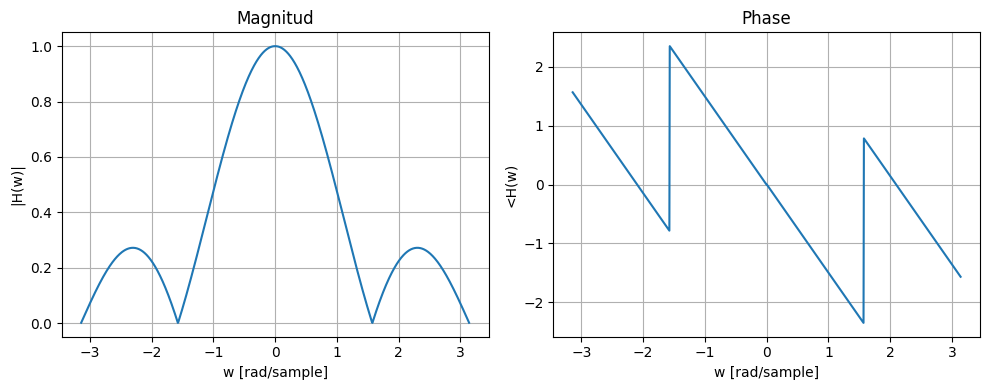

In [44]:
#Cridem la funció per a diferents valors de N
N = 4
coefficients = np.ones(N)/N
plot_frequency_response(coefficients, 1024)

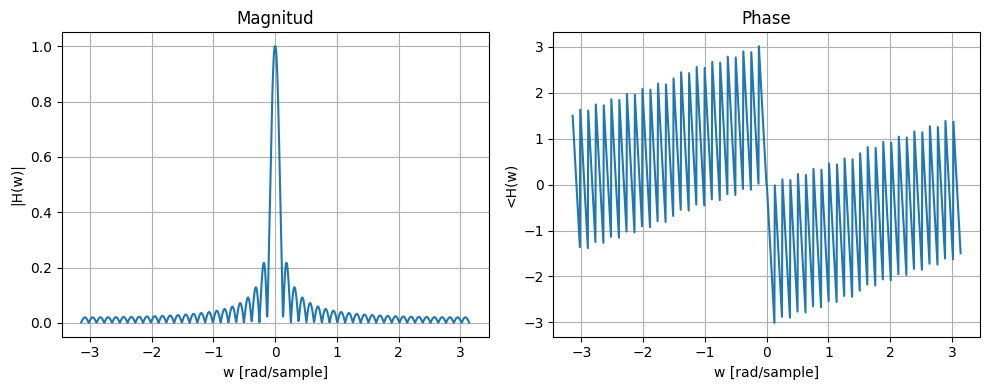

In [45]:
N = 50
h = np.ones(N)/N
plot_frequency_response(h, 1024)

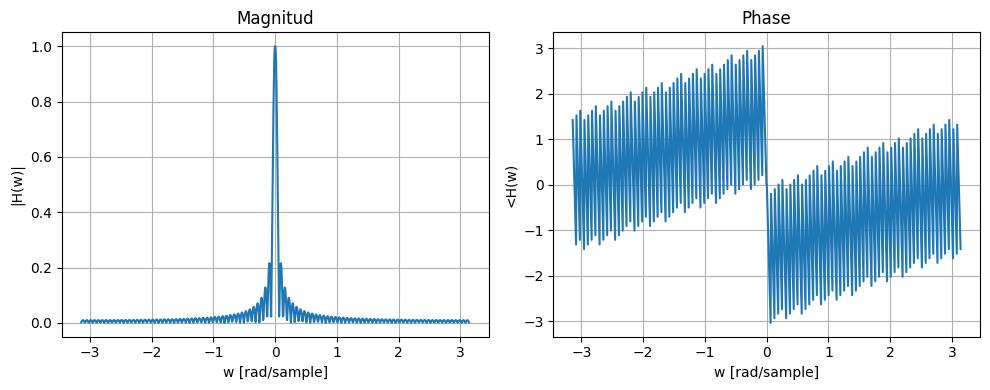

In [46]:
N = 100
h = np.ones(N)/N
plot_frequency_response(h, 1024)

2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

Podem observar com el four-averaging filter és suau i atenua lleugerament les freqüències altes. En canvi, a mesura que augmentem N eliminem de manera més efectiva les freqüències altes i només deixa passar les que són més baixes, generant un low-pass filter.

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [61]:
#Creem la funció add_interference
def add_interference(x, fs):
  t = np.arange(len(x)) / fs #Creem un vector de 0 fins la length del senyal
  f_interf = 0.5 * (fs / 2)  #Utilitzem la meitat de la freqüència de Nyquist (Podria ser algun altre valor)
  A_interf = 0.5 * np.max(np.abs(x)) #Utilitzem la meitat de l'amplitud màxima del senyal original

  interference = A_interf * np.cos(2*np.pi*f_interf*t) #Generem una sinusoide amb l'amplitud i freqüència escollida
  x_interf = x + interference #Afegim l'interferència al senyal original

  return x_interf #Retornem el senyal interferit

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [62]:
from IPython.display import Audio

x_interf = add_interference(ref, fs) #Utilitzem la funció creada a l'apartat 3.1 per crear el senyal interferit
samples = int(0.1 * fs) #Definim quantes mostres hi haurà al gràfic

#Imprimim els dos senyals
plot_signals([ref[:samples],  x_interf[:samples]], fs, name=['Referència', 'Interferit'])

print("Importem el Senyal Interferit")
display(Audio(x_interf, rate = fs)) #Escoltem el senyal alterat

Importem el Senyal Interferit


3.3 Compare the spectrograms of the reference signal and the interference signal. 

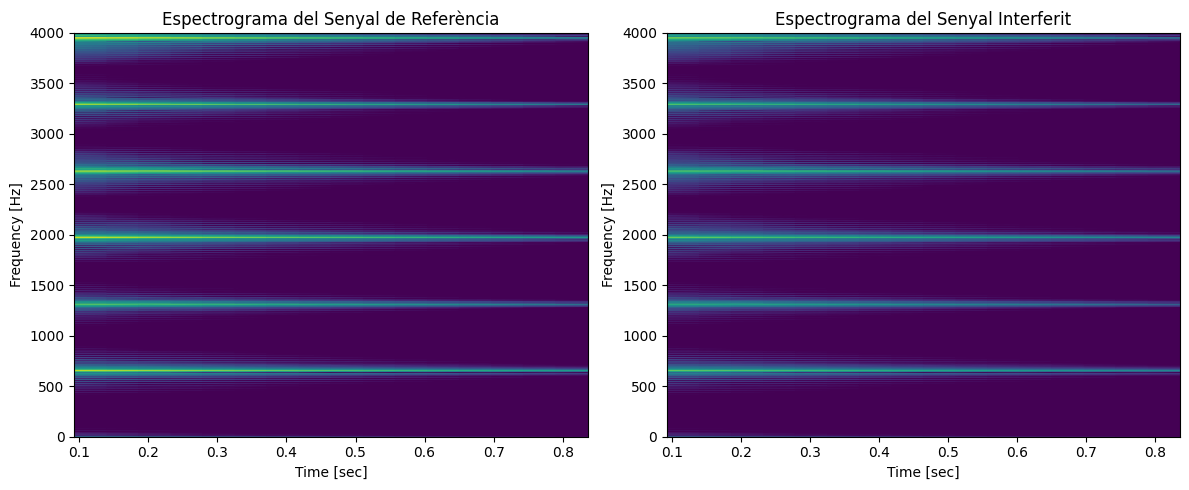

In [64]:
from scipy.signal import spectrogram 

window_length = 8192 #Definim el nombre de mostres

#Calculem els espectrogrames
ff, tt, Sxx = spectrogram(ref, fs, nperseg=window_length, noverlap=window_length / 2)
ff, tt, Sxx_interf = spectrogram(x_interf, fs, nperseg=window_length, noverlap=window_length / 2)

#Creem la figura, ja que la dividirem en dos
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plot_spectrogram(ff, tt, Sxx)
plt.title('Espectrograma del Senyal de Referència')
plt.ylim([0, 4000])

plt.subplot(1,2,2)
plot_spectrogram(ff, tt, Sxx_interf)
plt.title('Espectrograma del Senyal Interferit')
plt.ylim([0, 4000])

plt.tight_layout()
plt.show()

Podem observar com encara hi ha diferències molt petites entre el senyal original i l'alterat. Les freqüències inferiors a 1000 Hz s'assemblen una mica més, mentre que les freqüències més altes es veuen afectades per la interferència, que introdueix soroll addicional.

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [65]:
def remove_interference(x, fs):
  """Applies nulling filter to remove an interference at 1000 Hz

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  f_interf = 1000 #Assignem la freqüència que ens imposa l'enunciat
  w_n = 2 * np.pi * f_interf / fs #Normalitzem la freqüència angular
  b = [1, -2 * np.cos(w_n), 1] #Coeficients del filtre FIR de 3 punts
  y = np.convolve(x, b, mode='same') #Apliquem el filtre FIR al senyal original
  
  return y #Retornem el senyal filtrejat

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

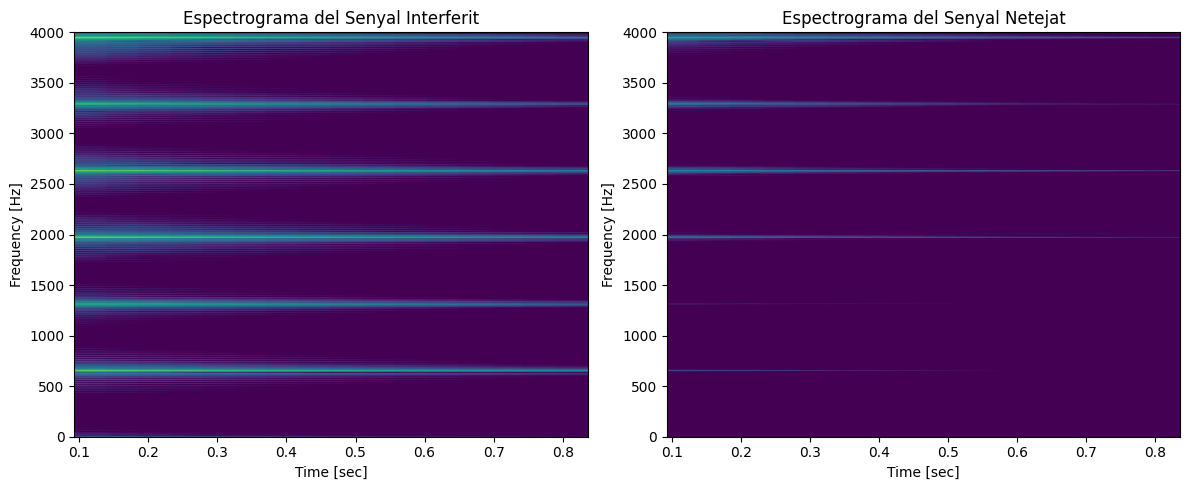

Importem el Senyal Interferit


Importem el Senyal Netejat


In [67]:
#Cridem la funció per obtenir el senyal netejat
x_clean = remove_interference(x_interf, fs) 

window_length = 8192
ff, tt, Sxx_interf = spectrogram(x_interf, fs, nperseg=window_length, noverlap=window_length / 2)
ff, tt, Sxx_remove = spectrogram(x_clean, fs, nperseg=window_length, noverlap=window_length / 2)

#Definim la figura per dividir-la en 2
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plot_spectrogram(ff, tt, Sxx_interf)
plt.title('Espectrograma del Senyal Interferit')
plt.ylim([0, 4000])

plt.subplot(1,2,2)
plot_spectrogram(ff, tt, Sxx_remove)
plt.title('Espectrograma del Senyal Netejat')
plt.ylim([0, 4000])

plt.tight_layout()
plt.show()

print("Importem el Senyal Interferit")
display(Audio(x_interf, rate = fs)) #Escoltem el senyal interferit
print("Importem el Senyal Netejat")
display(Audio(x_clean, rate = fs)) #Escoltem el senyal netejat

Podem observar com l'spectrograma del senyal interferit conté una forta interferència a 1000 Hz (línia horitzontal). Després d'aplicar un notch-filter, podem veure com aquesta línia ha desaparegut, ja que aquest filtre funciona col·locant un 0 exactament a una certa freqüència determinada, que en aquest cas ha estat de1000 Hz.